# 1. Imports

In [89]:
import importlib
import strategy.prep  # or whatever your module path is
importlib.reload(strategy.prep)
from strategy.prep import prepare_universe

In [90]:
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_ta as ta
import matplotlib.pyplot as plt


# Pull S&P 500 tickers

In [91]:
import pandas as pd
import requests
from io import StringIO


# URL
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

# Add browser headers (fix 403)
headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"
}

# Get page
response = requests.get(url, headers=headers)

# Parse tables
tables = pd.read_html(StringIO(response.text))

# First table is S&P 500 list
sp500 = tables[0]

# Extract tickers
tickers = sp500['Symbol'].tolist()

# Fix Yahoo format (BRK.B -> BRK-B)
tickers = [t.replace('.', '-') for t in tickers]

print("Total tickers:", len(tickers))
print(tickers[:10])

Total tickers: 503
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [92]:
pd.Series(tickers).to_csv("sp500_tickers.csv", index=False, header=False)

# load top 150 liquid stocks

In [93]:
import pandas as pd

tickers = pd.read_csv("sp500_tickers.csv", header=None)[0].tolist()

print(tickers[:20])
print(len(tickers))

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL']
503


In [94]:
tickers = pd.read_csv("sp500_tickers.csv", header=None)[0]

tickers = (
    tickers
    .astype(str)
    .str.strip()
    .str.replace('.', '-', regex=False)
)

tickers = tickers[tickers != ""].tolist()

print("Clean tickers:", len(tickers))

Clean tickers: 503


In [95]:
import yfinance as yf

test = yf.download(tickers[:10], start="2020-01-01", end="2024-01-01")

print(test.head())

[**********            20%                       ]  2 of 10 completed

[*********************100%***********************]  10 of 10 completed

Price           Close                                                \
Ticker              A       ABBV        ABT         ACN        ADBE   
Date                                                                  
2020-01-02  82.210434  69.266151  77.813850  192.514999  334.429993   
2020-01-03  80.890495  68.608681  76.865265  192.194412  331.809998   
2020-01-06  81.129631  69.150131  77.267975  190.939346  333.709991   
2020-01-07  81.378311  68.755638  76.838409  186.816971  333.390015   
2020-01-08  82.181786  69.242943  77.151627  187.183411  337.869995   

Price                                                               ...  \
Ticker            AES        AFL        AMD        AOS         MMM  ...   
Date                                                                ...   
2020-01-02  15.918977  45.964325  49.099998  42.552330  120.143433  ...   
2020-01-03  15.736179  45.645557  48.599998  42.178192  119.108810  ...   
2020-01-06  15.918977  45.516323  48.389999  42.445423  

In [96]:
import yfinance as yf
test = yf.download(['AAPL','MSFT','NVDA'], start='2020-01-01', end='2024-01-01', progress=False)
print(test.head())

Price           Close                             High                        \
Ticker           AAPL        MSFT      NVDA       AAPL        MSFT      NVDA   
Date                                                                           
2020-01-02  72.400536  152.158371  5.970755  72.460799  152.262577  5.970755   
2020-01-03  71.696640  150.263748  5.875187  72.455958  151.523684  5.918990   
2020-01-06  72.267944  150.652115  5.899825  72.306514  150.718434  5.905051   
2020-01-07  71.928055  149.278564  5.971252  72.533095  151.258458  6.017045   
2020-01-08  73.085114  151.656342  5.982450  73.386431  152.328945  6.023764   

Price             Low                             Open                        \
Ticker           AAPL        MSFT      NVDA       AAPL        MSFT      NVDA   
Date                                                                           
2020-01-02  71.156697  149.989017  5.891364  71.409800  150.415308  5.941886   
2020-01-03  71.472462  149.733252  5.82

In [97]:
import yfinance as yf
import pandas as pd

test_tickers = ["AAPL", "MSFT", "GOOGL"]
raw = yf.download(test_tickers, start="2020-01-01", end="2024-01-01", group_by="ticker", progress=False)

print("Column MultiIndex levels:")
print("  Level 0:", raw.columns.get_level_values(0).unique().tolist())
print("  Level 1:", raw.columns.get_level_values(1).unique().tolist())

price_fields = {'Open', 'High', 'Low', 'Close', 'Volume'}
level0_vals = set(raw.columns.get_level_values(0))
level1_vals = set(raw.columns.get_level_values(1))

print("\nprice_fields & level1_vals:", price_fields & level1_vals)
print("price_fields & level0_vals:", price_fields & level0_vals)

if price_fields & level1_vals:
    ticker_level, price_level = 0, 1
else:
    ticker_level, price_level = 1, 0

print(f"\nticker_level={ticker_level}, price_level={price_level}")

ticker_labels = raw.columns.get_level_values(ticker_level).unique()
print("ticker_labels:", ticker_labels.tolist())

for t in ticker_labels:
    print(f"\n--- {t} ---")
    print(f"  in tickers list: {t in test_tickers}")
    try:
        if ticker_level == 0:
            sub = raw.loc[:, (t, slice(None))]
            sub.columns = sub.columns.droplevel(0)
        else:
            sub = raw.loc[:, (slice(None), t)]
            sub.columns = sub.columns.droplevel(1)
        print(f"  sub.columns: {sub.columns.tolist()}")
        print(f"  all NaN: {sub.isna().all().all()}")
    except Exception as e:
        print(f"  EXCEPTION: {e}")

Column MultiIndex levels:
  Level 0: ['AAPL', 'GOOGL', 'MSFT']
  Level 1: ['Open', 'High', 'Low', 'Close', 'Volume']

price_fields & level1_vals: {'High', 'Close', 'Open', 'Low', 'Volume'}
price_fields & level0_vals: set()

ticker_level=0, price_level=1
ticker_labels: ['AAPL', 'GOOGL', 'MSFT']

--- AAPL ---
  in tickers list: True
  sub.columns: ['Open', 'High', 'Low', 'Close', 'Volume']
  all NaN: False

--- GOOGL ---
  in tickers list: True
  sub.columns: ['Open', 'High', 'Low', 'Close', 'Volume']
  all NaN: False

--- MSFT ---
  in tickers list: True
  sub.columns: ['Open', 'High', 'Low', 'Close', 'Volume']
  all NaN: False


In [98]:
df, tickers_used = prepare_universe(
    sp500_csv="sp500_tickers.csv",
    dynamic=True,
    top_n=150,
    start="2020-01-01",
    end="2024-01-01",
    vol_window=60
)

$GEV: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
$Q: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
$Q: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
$SOLV: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
$SOLV: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
$SNDK: possibly delisted; no price data found  (1d 2020-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1577854800, endDate = 1704085200")
$SNDK: possibly delisted; no 

Tickers used:              150
Candidate trades (entries): 489
Avg return:                0.0073
Win rate:                  0.5629


In [99]:
import yfinance as yf
import numpy as np
import pandas as pd

def download_price_data_test(tickers, start, end):
    raw = yf.download(tickers, start=start, end=end, group_by="ticker", progress=False)
    
    out_frames = []
    full_idx = pd.date_range(start=start, end=end, freq='B')
    
    price_fields = {'Open', 'High', 'Low', 'Close', 'Volume'}
    level0_vals = set(raw.columns.get_level_values(0))
    level1_vals = set(raw.columns.get_level_values(1))

    if price_fields & level1_vals:
        ticker_level = 0
    else:
        ticker_level = 1

    ticker_labels = raw.columns.get_level_values(ticker_level).unique()
    tickers_upper = [t.strip().upper() for t in tickers]

    for t in ticker_labels:
        if t not in tickers_upper:
            continue
        try:
            if ticker_level == 0:
                sub = raw.loc[:, (t, slice(None))]
                sub.columns = sub.columns.droplevel(0)
            else:
                sub = raw.loc[:, (slice(None), t)]
                sub.columns = sub.columns.droplevel(1)
        except Exception:
            continue

        if sub.isna().all().all():
            continue

        sub = sub.rename(columns=lambda c: str(c).lower())
        sub.index.name = 'date'
        sub = sub.reset_index()
        sub = sub.rename(columns={'Date': 'date', 'Datetime': 'date', 'index': 'date'})
        sub['ticker'] = t

        for col in ['open', 'high', 'low', 'close', 'volume']:
            if col not in sub.columns:
                sub[col] = np.nan

        sub = sub[['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']]
        s2 = sub.set_index('date').reindex(full_idx).reset_index().rename(columns={'index': 'date'})
        s2['ticker'] = t
        out_frames.append(s2)

    print(f"Frames collected: {len(out_frames)}")
    if out_frames:
        combined = pd.concat(out_frames, ignore_index=True, sort=False)
        print(combined.head())
        return combined

download_price_data_test(["AAPL", "MSFT", "GOOGL"], "2020-01-01", "2024-01-01")

Frames collected: 3
Price       date ticker        open        high         low       close  \
0     2020-01-01   MSFT         NaN         NaN         NaN         NaN   
1     2020-01-02   MSFT  150.415353  152.262622  149.989062  152.158417   
2     2020-01-03   MSFT  149.979549  151.523669  149.733237  150.263733   
3     2020-01-06   MSFT  148.804876  150.718465  148.264897  150.652145   
4     2020-01-07   MSFT  150.926874  151.258427  149.032236  149.278534   

Price      volume  
0             NaN  
1      22622100.0  
2      21116200.0  
3      20813700.0  
4      21634100.0  


Price,date,ticker,open,high,low,close,volume
0,2020-01-01,MSFT,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,MSFT,150.415353,152.262622,149.989062,152.158417,22622100.0
2,2020-01-03,MSFT,149.979549,151.523669,149.733237,150.263733,21116200.0
3,2020-01-06,MSFT,148.804876,150.718465,148.264897,150.652145,20813700.0
4,2020-01-07,MSFT,150.926874,151.258427,149.032236,149.278534,21634100.0
...,...,...,...,...,...,...,...
3127,2023-12-26,AAPL,191.619364,191.896484,190.847385,191.065125,28919300.0
3128,2023-12-27,AAPL,190.510875,191.510485,189.125261,191.164078,48087700.0
3129,2023-12-28,AAPL,192.143885,192.658543,191.183857,191.589645,34049900.0
3130,2023-12-29,AAPL,191.906385,192.401245,189.758698,190.550476,42672100.0


In [100]:
print("Tickers used:", len(tickers_used))

Tickers used: 150


In [101]:
import yfinance as yf

test_tickers = ["AAPL", "MSFT", "GOOGL"]
raw = yf.download(test_tickers, start="2020-01-01", end="2024-01-01", group_by="ticker", progress=False)

print(type(raw.columns))
print(raw.columns[:10])
print(raw.head(2))

<class 'pandas.MultiIndex'>
MultiIndex([( 'MSFT',   'Open'),
            ( 'MSFT',   'High'),
            ( 'MSFT',    'Low'),
            ( 'MSFT',  'Close'),
            ( 'MSFT', 'Volume'),
            ('GOOGL',   'Open'),
            ('GOOGL',   'High'),
            ('GOOGL',    'Low'),
            ('GOOGL',  'Close'),
            ('GOOGL', 'Volume')],
           names=['Ticker', 'Price'])
Ticker            MSFT                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2020-01-02  150.415353  152.262622  149.989062  152.158417  22622100   
2020-01-03  149.979549  151.523669  149.733237  150.263733  21116200   

Ticker          GOOGL                                                  AAPL  \
Price            Open       High        Low      Close    Volume       Open   
Date                                                                          
2020-

# 2. load data

In [102]:
# Load universe: prefer `tickers_used` (from prepare_universe).
# Fallback: read top 150 tickers from sp500_tickers.csv and clean formatting.
try:
    tickers = tickers_used
    print(f'Registered tickers from prepare_universe: {len(tickers)}')
except NameError:
    tickers = pd.read_csv('sp500_tickers.csv', header=None)[0]
    tickers = (
        tickers.astype(str)
        .str.strip()
        .str.replace('.', '-', regex=False)
        .tolist()
    )[:150]  # take top 150 as a sensible default
    print(f'Falling back to first {len(tickers)} tickers from sp500_tickers.csv')

dfs = []
start = '2020-01-01'
end = '2024-01-01'
# Download per-ticker to avoid MultiIndex complexity and handle missing tickers
for i, ticker in enumerate(tickers, start=1):
    try:
        temp = yf.download(ticker, start=start, end=end, progress=False)
    except Exception as e:
        print(f'Error downloading {ticker}: {e} -- skipping')
        continue
    if temp is None or temp.empty:
        print(f'No data for {ticker}, skipping')
        continue
    # Keep only standard fields and normalize column names
    cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    for c in cols:
        if c not in temp.columns:
            temp[c] = pd.NA
    temp = temp[cols].copy()
    temp.columns = ['open', 'high', 'low', 'close', 'volume']
    temp.index.name = 'date'
    temp = temp.reset_index()
    temp['ticker'] = ticker
    dfs.append(temp)
    if i % 25 == 0:
        print(f'Downloaded {i}/{len(tickers)} tickers...')

if dfs:
    df = pd.concat(dfs, ignore_index=True, sort=False)
    # drop rows that are fully missing for prices
    df = df.dropna(subset=['open', 'high', 'low', 'close'])
else:
    # create empty DataFrame with expected columns if nothing downloaded
    df = pd.DataFrame(columns=['date', 'open', 'high', 'low', 'close', 'volume', 'ticker'])
    print('No price data downloaded for any tickers')

Registered tickers from prepare_universe: 150
Downloaded 25/150 tickers...
Downloaded 25/150 tickers...
Downloaded 50/150 tickers...
Downloaded 50/150 tickers...
Downloaded 75/150 tickers...
Downloaded 75/150 tickers...
Downloaded 100/150 tickers...
Downloaded 100/150 tickers...
Downloaded 125/150 tickers...
Downloaded 125/150 tickers...
Downloaded 150/150 tickers...
Downloaded 150/150 tickers...


# 3. Feature Engineering

In [103]:
df['ema_200'] = df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=200).mean())
df['ema_50'] = df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=50).mean())
df['ema_20'] = df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=20).mean())

# RSI
df['rsi'] = df.groupby('ticker')['close'].transform(lambda x: ta.rsi(x, length=14))

# True range and ATR(14)
high = df['high']
low = df['low']
close = df['close']
df['tr'] = pd.concat([
    high - low,
    (high - close.shift()).abs(),
    (low - close.shift()).abs()
], axis=1).max(axis=1)

df['atr_14'] = df.groupby('ticker')['tr'].transform(lambda x: x.rolling(14, min_periods=1).mean())

# Volume moving average (20) for a simple liquidity filter
df['volume_ma20'] = df.groupby('ticker')['volume'].transform(lambda x: x.rolling(20, min_periods=1).mean())

# 4. Build Strategy Logic

In [104]:
# Trend (price above long-term ema and shorter EMAs aligned)
df['trend'] = (
    (df['close'] > df['ema_200']) &
    (df['ema_20'] > df['ema_50']) &
    (df['ema_50'] > df['ema_200'])
)

# Pullback: price is below the short EMA but above long-term EMA
df['pullback'] = (
    (df['close'] < df['ema_20']) &
    (df['close'] > df['ema_200'])
)

# Oversold and trigger (RSI-based)
df['oversold'] = df['rsi'] < 45

df['trigger'] = (
    (df['rsi'] > df['rsi'].shift(1)) &
    (df['rsi'].shift(1) < 40)
)

# Trend slope: smoother multi-period slope of the ema_200 (20-period diff)
# Use diff(20) to reduce noise; tune window as desired
df['trend_slope'] = df.groupby('ticker')['ema_200'].transform(lambda x: x.diff(20))
df['trend_slope_flag'] = df['trend_slope'] > 0

# Price-strength: close higher than previous close for same ticker
df['price_strength'] = (
    df.groupby('ticker')['close'].transform(lambda x: x > x.shift(1))
).fillna(False)

# Volume filter
df['volume_ok'] = df['volume'] > df['volume_ma20']

# ATR filter (optional): avoid extremely low-volatility entries
# Example threshold: require ATR > median ATR per ticker (tunable)
df['atr_median'] = df.groupby('ticker')['atr_14'].transform('median')
df['atr_ok'] = df['atr_14'] > (0.5 * df['atr_median'])

# Base entry: combine filters; keep as a separate column so we can post-process
# Note: do not yet enforce non-overlap here
df['entry_base'] = (
    df['trend'] &
    df['pullback'] &
    df['oversold'] &
    df['trigger'] &
    df['trend_slope_flag'] &
    df['price_strength'] &
    df['volume_ok'] &
    df['atr_ok']
)

# For compatibility with later code, initialize df['entry'] from entry_base
df['entry'] = df['entry_base'].astype(bool)

# trend strength filter

In [105]:
# Keep trend_strength column for backwards compatibility but use the smoother slope flag
# Replace prior 1-period diff with the 20-period slope-based flag
# (This cell no longer forces entry; it just computes the flag.)
# Note: df['trend_slope_flag'] computed in the strategy logic cell is the primary source
if 'trend_slope_flag' not in df.columns:
    df['trend_slope_flag'] = df.groupby('ticker')['ema_200'].transform(lambda x: x.diff(20) > 0)

# legacy alias
df['trend_strength'] = df['trend_slope_flag']

# 5. Entry Signal

In [106]:
# Final entry signal (still allows a later non-overlap cleaning step)
# This re-assembles the entry using the precomputed flags so it's explicit and easy to audit
df['entry'] = (
    df['trend'] &
    df['pullback'] &
    df['oversold'] &
    df['trigger'] &
    df['trend_slope_flag'] &
    df['price_strength'] &
    df['volume_ok'] &
    df['atr_ok']
)

# Quick sanity check: count candidate entries
print('Candidate entries (before de-overlap):', int(df['entry'].sum()))

Candidate entries (before de-overlap): 628


In [107]:
df['entry'].sum()

np.int64(628)

# Add Stop Loss

In [108]:
# Aligned stop calculations: min low in the next 5 trading days (excluding today)
# Shift by -1 then rolling to aggregate the following 5 days
df['min_low_next_5'] = df.groupby('ticker')['low'].transform(lambda s: s.shift(-1).rolling(5, min_periods=1).min())
# Stop return based on that min low
df['stop_return'] = (df['min_low_next_5'] - df['close']) / df['close']

# ATR-based stop (distance = k * ATR)
k = 2.0
df['stop_price_atr'] = df['close'] - k * df['atr_14']
df['stop_return_atr'] = (df['stop_price_atr'] - df['close']) / df['close']

# Sanity counts
print('Rows with min_low_next_5 NaN (end of series):', int(df['min_low_next_5'].isna().sum()))

Rows with min_low_next_5 NaN (end of series): 0


# forward returns

In [109]:
# Correct future return: explicit future close shifted by 5 days
# This is clearer and less error-prone than pct_change(...).shift(-5)
df['future_close_5'] = df.groupby('ticker')['close'].shift(-5)
df['forward_return_5'] = df['future_close_5'] / df['close'] - 1

# Optional: if you want to see how many NaNs (end of series) exist
print('Future-close NaNs (end of series):', int(df['future_close_5'].isna().sum()))

Future-close NaNs (end of series): 750


# Results?

In [117]:
from strategy.performance import analyze_performance
import pandas as pd
import numpy as np


def _fmt(x):
    """Format a numeric value for display."""
    if x is None:
        return 'n/a'
    try:
        if isinstance(x, float) and (np.isnan(x) or np.isinf(x)):
            return str(x)
        return f'{x:.4f}'
    except Exception:
        return str(x)


def get_returns_from_df(df):
    """
    Always compute returns directly from the current dataframe.
    No reliance on global variables like `results` or `df_results`.
    """
    if not isinstance(df, pd.DataFrame):
        raise ValueError("df must be a pandas DataFrame")

    # Prefer non-overlapping realized trades
    if 'entry_nonoverlap' in df.columns and 'actual_return' in df.columns:
        col = df['entry_nonoverlap']
        is_bool_like = col.dtype == bool or col.isin([0, 1]).all()
        if is_bool_like:
            returns = df.loc[col.astype(bool), 'actual_return'].dropna()
            if len(returns) > 0:
                return returns

    # Fallback options (less ideal)
    for col in ['actual_return', 'forward_return_5', 'return', 'pnl', 'profit']:
        if col in df.columns:
            returns = df[col].dropna()
            if len(returns) > 0:
                print(f"⚠️ Using fallback column: {col}")
                return returns

    return pd.Series(dtype=float)


# --- MAIN EXECUTION ---
if __name__ == "__main__":

    # Validate df exists before proceeding
    if 'df' not in dir() or df is None:
        raise RuntimeError("df is not defined. Run your pipeline first.")

    returns = get_returns_from_df(df)

    if returns.empty:
        print("No valid returns found in df. Check columns like `actual_return` and `entry_nonoverlap`.")
    else:
        metrics = analyze_performance(returns, interpret=True)

        # Extra info: number of trades and estimated trades per year
        n_trades = len(returns)
        trades_per_year = None

        try:
            idx = returns.index
            if isinstance(idx, pd.DatetimeIndex) and len(idx) > 1:
                span_days = max(1, (idx.max() - idx.min()).days)
                years = span_days / 365.25
                trades_per_year = int(round(n_trades / years)) if years > 0 else None
        except AttributeError:
            trades_per_year = None

        print('\nPerformance summary:')
        print(f'  Number of trades:       {n_trades}')
        if trades_per_year is not None:
            print(f'  Estimated trades / year: {trades_per_year}')
        print(f'  Mean return:            {_fmt(metrics.get("mean_return"))}')
        print(f'  Median return:          {_fmt(metrics.get("median_return"))}')
        print(f'  Std dev:                {_fmt(metrics.get("std"))}')
        print(f'  Sharpe ratio:           {_fmt(metrics.get("sharpe"))}')
        print(f'  Win rate:               {_fmt(metrics.get("win_rate"))}')
        print(f'  Max drawdown:           {_fmt(metrics.get("max_drawdown"))}')

Performance interpretation:
 - Sharpe: -4.9374; weak
 - Expectancy: -0.0085; not positive
 - Profit factor: 0.5631; weak

Performance summary:
  Number of trades:       485
  Mean return:            n/a
  Median return:          n/a
  Std dev:                n/a
  Sharpe ratio:           -4.9374
  Win rate:               0.3361
  Max drawdown:           -0.9883


# backtest

/var/folders/wj/6qpy6cgs06vbbl8fwlxnyg7m0000gn/T/ipykernel_25509/2271168829.py:28: UserWarning: Column 'actual_return' not found — falling back to 'forward_return_5' for PnL. Run the combine-stop cell to compute ATR/hard-stop returns.
  warnings.warn("Column 'actual_return' not found — falling back to 'forward_return_5' for PnL. Run the combine-stop cell to compute ATR/hard-stop returns.")


Trades: 485
Avg Return: 0.007945195519514388
Win Rate: 0.5567010309278351
Hold lengths -> avg: 4.62, min: 1, max: 5
Final Capital: 276914.6819843628
Total Return: 26.691468198436276


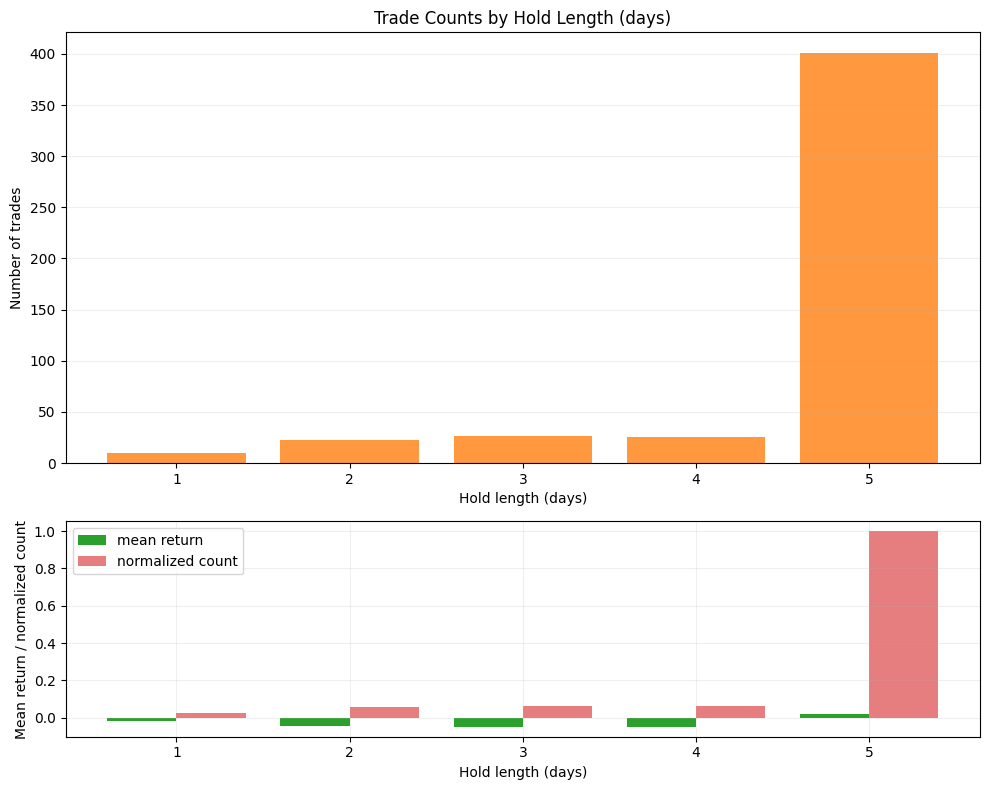

In [111]:
# Backtest: enforce non-overlapping trades, compute metrics, hold lengths and equity curve
# Helper to remove overlapping entries within a holding window (per ticker)
def remove_overlaps(entries, hold=5):
    # entries: pandas Series of booleans for a single ticker
    arr = entries.astype(int).values
    out = np.zeros_like(arr)
    i = 0
    n = len(arr)
    while i < n:
        if arr[i]:
            out[i] = 1
            i += hold  # skip the holding window (no new entries)
        else:
            i += 1
    return pd.Series(out.astype(bool), index=entries.index)

# Apply per ticker
hold_window = 5
# Reset index to ensure unique integer index labels and avoid reindexing issues later
# (original df may have duplicate labels after concat). This keeps assignment safe.
df = df.reset_index(drop=True)

df['entry_nonoverlap'] = df.groupby('ticker')['entry'].transform(lambda s: remove_overlaps(s, hold=hold_window))

# Ensure actual_return exists; if not, fall back to forward_return_5 (and warn)
if 'actual_return' not in df.columns:
    import warnings
    warnings.warn("Column 'actual_return' not found — falling back to 'forward_return_5' for PnL. Run the combine-stop cell to compute ATR/hard-stop returns.")
    if 'forward_return_5' in df.columns:
        df['actual_return'] = df['forward_return_5'].copy()
    else:
        df['actual_return'] = np.nan

# Compute hold lengths and exit prices per entry by scanning the next `hold_window` days
# We'll operate per-ticker to avoid crossing boundaries
df['hold_length'] = np.nan
df['exit_price'] = np.nan
for ticker, group in df.groupby('ticker'):
    idx = group.index
    lows = group['low'].values
    sp = group['stop_price_atr'].values if 'stop_price_atr' in group.columns else np.full(len(group), np.nan)
    fc = group['future_close_5'].values if 'future_close_5' in group.columns else np.full(len(group), np.nan)
    en = group['entry_nonoverlap'].values
    n = len(group)
    hl = np.full(n, np.nan)
    ep = np.full(n, np.nan)
    for i in range(n):
        if not en[i]:
            continue
        exit_offset = None
        # scan next days for stop hit
        for offset in range(1, hold_window + 1):
            j = i + offset
            if j >= n:
                break
            if not np.isnan(sp[i]) and lows[j] <= sp[i]:
                exit_offset = offset
                ep[i] = sp[i]
                break
        if exit_offset is None:
            # if we have a future close at day `hold_window`, exit at that price
            if not np.isnan(fc[i]):
                exit_offset = hold_window
                ep[i] = fc[i]
            else:
                exit_offset = np.nan
        hl[i] = exit_offset
    # assign using a Series to ensure index alignment and avoid length mismatch errors
    df.loc[idx, 'hold_length'] = pd.Series(hl, index=idx)
    df.loc[idx, 'exit_price'] = pd.Series(ep, index=idx)

# Use actual_return for realized PnL
results = df.loc[df['entry_nonoverlap'], 'actual_return'].dropna()

print("Trades:", len(results))
print("Avg Return:", results.mean() if len(results) > 0 else float('nan'))
print("Win Rate:", (results > 0).mean() if len(results) > 0 else float('nan'))

# Hold length stats (on realized trades)
hold_lengths = df.loc[df['entry_nonoverlap'], 'hold_length'].dropna().astype(int)
if len(hold_lengths) > 0:
    avg_hold = hold_lengths.mean()
    min_hold = hold_lengths.min()
    max_hold = hold_lengths.max()
    print(f"Hold lengths -> avg: {avg_hold:.2f}, min: {min_hold}, max: {max_hold}")
else:
    print('No hold length data available')

# Simple equity curve assuming full allocation per trade sequentially
initial_capital = 10000
capital = initial_capital
equity = []
for r in results:
    capital *= (1 + r)
    equity.append(capital)

print("Final Capital:", capital if len(equity) > 0 else initial_capital)
print("Total Return:", (capital / initial_capital - 1) if len(equity) > 0 else 0.0)

# Store results for plotting
df_results = results.copy() if len(results) > 0 else pd.Series(dtype=float)

# Detailed hold-length visualization
import matplotlib.pyplot as plt

hl_series = hold_lengths if 'hold_lengths' in locals() else pd.Series(dtype=float)
if len(hl_series) == 0:
    print('No hold-lengths to plot.')
else:
    fig, axs = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [2, 1]})

    # Top: counts per hold length
    counts = hl_series.value_counts().sort_index()
    axs[0].bar(counts.index.astype(str), counts.values, color='C1', alpha=0.8)
    axs[0].set_title('Trade Counts by Hold Length (days)')
    axs[0].set_xlabel('Hold length (days)')
    axs[0].set_ylabel('Number of trades')
    axs[0].grid(axis='y', alpha=0.2)

    # Bottom: mean return and count per hold length
    grouped = df[df['entry_nonoverlap']].groupby(df['hold_length']).agg(
        mean_return=('actual_return', 'mean'),
        std_return=('actual_return', 'std'),
        count=('actual_return', 'count')
    ).dropna().sort_index()

    x = grouped.index.astype(int)
    axs[1].bar(x - 0.2, grouped['mean_return'], width=0.4, color='C2', label='mean return')
    axs[1].bar(x + 0.2, grouped['count'] / grouped['count'].max(), width=0.4, color='C3', alpha=0.6, label='normalized count')
    axs[1].set_xlabel('Hold length (days)')
    axs[1].set_ylabel('Mean return / normalized count')
    axs[1].legend()
    axs[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


# combine stop loss

In [112]:
# Combine stop rules and compute actual returns per candidate entry
# Model simple slippage and commission costs
commission = 0.0005  # 0.05% per side (adjust as desired)
slippage = 0.0005   # 0.05% per side

# Start with forward return as the default outcome
df['actual_return'] = df['forward_return_5'].copy()

# If the min low in the next 5 days breaches the ATR-based stop, assume exit at ATR stop price
atr_stop_hit = df['min_low_next_5'] <= df['stop_price_atr']
df.loc[atr_stop_hit, 'actual_return'] = (df.loc[atr_stop_hit, 'stop_price_atr'] / df.loc[atr_stop_hit, 'close']) - 1

# If the min low breaches a fixed 3% hard stop (more conservative), cap the loss at -3%
df['actual_return'] = np.where(df['stop_return'] < -0.03, -0.03, df['actual_return'])

# Subtract round-trip slippage and commissions from realized returns (entry+exit)
df['actual_return'] = df['actual_return'] - (2 * slippage + 2 * commission)

# Some entries near the end will have NaN future returns; keep them as NaN
print('Non-NaN actual returns candidates:', int(df['actual_return'].notna().sum()))

Non-NaN actual returns candidates: 148462


# 7. Visualize

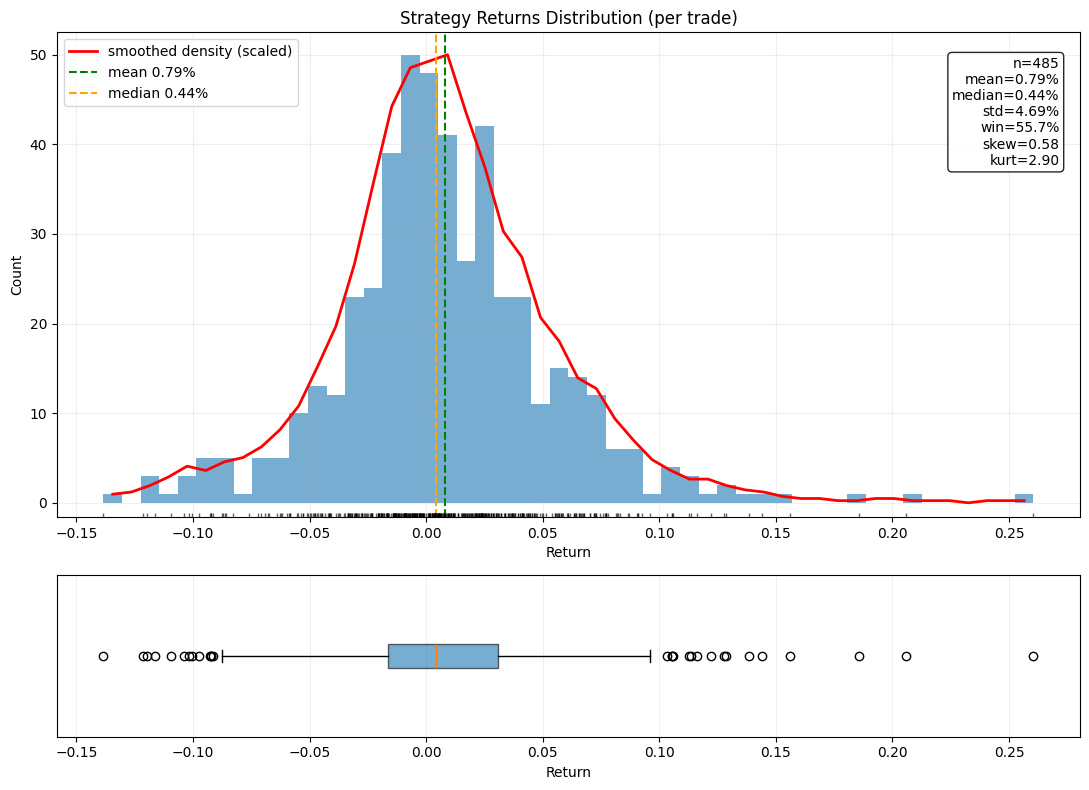

In [113]:
# Detailed strategy returns distribution plot
import numpy as np
import matplotlib.pyplot as plt

# Try to use the `results` Series if it exists; otherwise derive from df
try:
    res = results.dropna()
except Exception:
    res = df[df.get('entry_nonoverlap', df.get('entry', False))]['actual_return'].dropna()

if len(res) == 0:
    print('No trade results available to plot.')
else:
    mean = res.mean()
    median = res.median()
    std = res.std()
    skew = res.skew()
    kurt = res.kurt()
    win_rate = (res > 0).mean()
    count = len(res)

    fig, axs = plt.subplots(2, 1, figsize=(11, 8), gridspec_kw={'height_ratios': [3, 1]})

    bins = 50
    counts, bin_edges, patches = axs[0].hist(res, bins=bins, color='C0', alpha=0.6)

    # Smoothed density (simple moving-average on the histogram's density)
    hist_vals, edges = np.histogram(res, bins=bins, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    if hist_vals.max() > 0:
        smooth = np.convolve(hist_vals, np.ones(5) / 5, mode='same')
        # scale smooth curve to histogram height for visual alignment
        smooth_scaled = smooth * (counts.max() / (smooth.max() + 1e-12))
        axs[0].plot(centers, smooth_scaled, color='red', lw=2, label='smoothed density (scaled)')

    # Vertical lines for mean and median
    axs[0].axvline(mean, color='green', linestyle='--', lw=1.5, label=f'mean {mean:.2%}')
    axs[0].axvline(median, color='orange', linestyle='--', lw=1.5, label=f'median {median:.2%}')

    axs[0].set_title('Strategy Returns Distribution (per trade)')
    axs[0].set_xlabel('Return')
    axs[0].set_ylabel('Count')
    axs[0].grid(alpha=0.2)
    axs[0].legend()

    # Rug plot (small ticks at the bottom)
    ymin, ymax = axs[0].get_ylim()
    rug_y = ymin - 0.03 * (ymax - ymin)
    axs[0].plot(res.values, np.full_like(res.values, rug_y), '|', color='k', alpha=0.6)
    axs[0].set_ylim(rug_y, ymax)

    # Annotated stats box
    stats_txt = (
        f"n={count}\nmean={mean:.2%}\nmedian={median:.2%}\nstd={std:.2%}\nwin={win_rate:.1%}\nskew={skew:.2f}\nkurt={kurt:.2f}"
    )
    props = dict(boxstyle='round', facecolor='white', alpha=0.85)
    axs[0].text(0.98, 0.95, stats_txt, transform=axs[0].transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right', bbox=props)

    # Boxplot of returns for quick summary
    axs[1].boxplot(res.dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='C0', alpha=0.6))
    axs[1].set_xlabel('Return')
    axs[1].set_yticks([])
    axs[1].grid(axis='x', alpha=0.2)

    plt.tight_layout()
    plt.show()

# 8. Interpret Results (Think Like a Quant)

# Simple Backtester

In [114]:
initial_capital = 10000
capital = initial_capital

returns = []

for r in results:
    if pd.notna(r):
        capital *= (1 + r)
        returns.append(capital)

print("Final Capital:", capital)
print("Total Return:", (capital / initial_capital - 1))

Final Capital: 276914.6819843628
Total Return: 26.691468198436276


# Plot Equity Curve

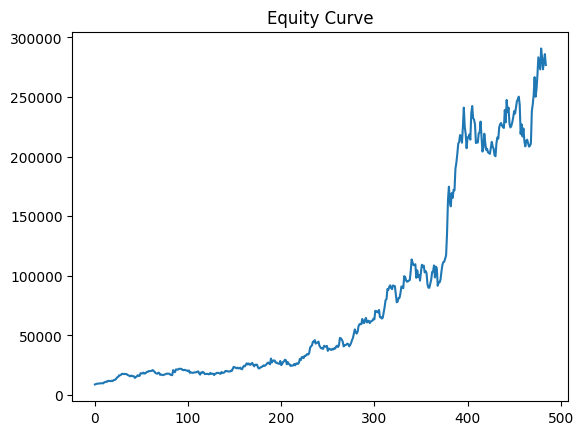

In [115]:
plt.plot(returns)
plt.title("Equity Curve")
plt.show()